In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
%matplotlib inline
import nibabel as nib
from tqdm import tqdm
import os

In [2]:
# load file
file_path = "../data/BraTS2021_00131/BraTS2021_00131_flair.nii.gz"
img = nib.load(file_path) 
img_data = img.get_fdata()

ground_truth_path = "../data/BraTS2021_00131/BraTS2021_00131_seg.nii.gz"
ground_truth_img = nib.load(ground_truth_path) 
ground_truth_data = ground_truth_img.get_fdata()

In [3]:
# file format
print("Type: ", type(img_data))
print("Shape: ", img_data.shape)

Type:  <class 'numpy.ndarray'>
Shape:  (240, 240, 155)


Slice shape:  (240, 240)


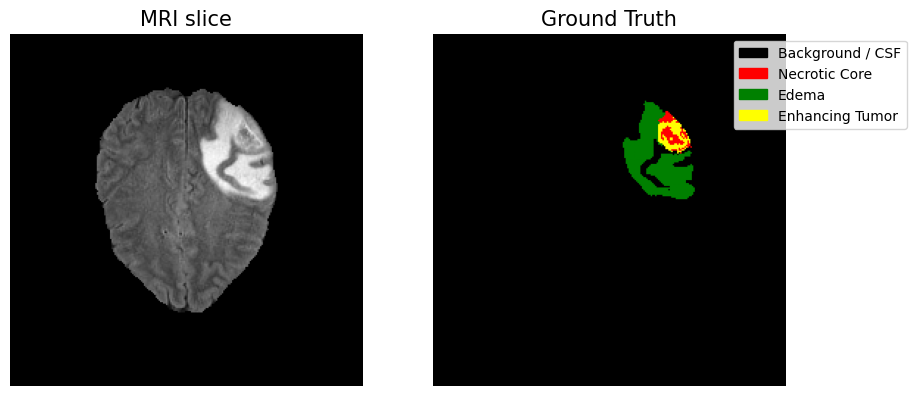

In [4]:
data_slice = img_data[: ,:, 100]
ground_truth_slice = ground_truth_data[:, :, 100]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
print("Slice shape: ", data_slice.shape)
plt.imshow(data_slice.T, cmap='gray', origin='lower')
plt.axis('off')
plt.title("MRI slice", fontsize=15)

# Black - CSF (healthy tissue) + Placeholder for label 3, which is non-existent in BraTS dataset
# Red - Necrotic core (label 1)
# Green - Edema (label 2)
# Yellow - Enhancing tumour (label 4)
colors = ["black", "red", "green", "black", "yellow"]
cmap = mcolors.ListedColormap(colors)

plt.subplot(1, 2, 2)
plt.imshow(ground_truth_slice.T, cmap=cmap, vmin=0, vmax=4, origin='lower')
plt.axis('off')
plt.title("Ground Truth", fontsize=15)

key_bg = mpatches.Patch(color="black", label="Background / CSF")
key_ncr = mpatches.Patch(color="red", label="Necrotic Core")
key_ed = mpatches.Patch(color="green", label="Edema")
key_et = mpatches.Patch(color="yellow", label="Enhancing Tumor")

plt.legend(
    handles=[key_bg, key_ncr, key_ed, key_et],
    bbox_to_anchor=(1.1, 1),
    loc="upper center",
)

In [ ]:
class SingleEncoderBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=input_channels,
            out_channels=output_channels, 
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        ) # We don't need bias if we have batch normalisation 
        self.batch_norm1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(
            in_channels=output_channels,
            out_channels=output_channels, 
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.batch_norm2 = nn.BatchNorm2d(output_channels)
        self.activation_fun = nn.ReLU()
        # self.pool = nn.MaxPool2d(
        #     kernel_size=2,
        #     stride=2
        # )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.activation_fun(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.activation_fun(x)

        # p = self.pool(x)
        return x

In [ ]:
class SingleDecoderBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.up_conv = nn.ConvTranspose2d(
            in_channels=input_channels,
            out_channels=output_channels, 
            kernel_size=2,
            stride=2
        ) # Mirrors the pooling layers from encoder 

        self.conv1 = nn.Conv2d(
            in_channels=output_channels *2,
            out_channels=output_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.batch_norm1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(
            in_channels=output_channels,
            out_channels=output_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.batch_norm2 = nn.BatchNorm2d(output_channels)
        self.activation_fun = nn.ReLU()
    
    def forward(self, input, skip_layer_input):
        input = self.up_conv(input)
        merged = torch.cat([input, skip_layer_input], axis=1)

        x = self.conv1(merged)
        x = self.batch_norm1(x)
        x = self.activation_fun(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.activation_fun(x)

        return x



In [ ]:
class Full2DUNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # input shape is (1, 1, 240, 240)
        # (batch size, channel size, (shape of img slice))
        self.encoder1 = SingleEncoderBlock(
            input_channels=in_channels,
            output_channels=64
        )
        # pool here
        self.encoder2 = SingleEncoderBlock(
            input_channels=64,
            output_channels=128
        )
        self.encoder3 = SingleEncoderBlock(
            input_channels=128,
            output_channels=256
        )
        self.encoder4 = SingleEncoderBlock(
            input_channels=256,
            output_channels=512
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(
                in_channels=512,
                out_channels=1024,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=1024,
                out_channels=1024,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(1024),
            nn.ReLU()
        )

        # up convolution here 
        self.decoder1 = SingleDecoderBlock(
            input_channels=1024, 
            output_channels=512
        )
        self.decoder2 = SingleDecoderBlock(
            input_channels=512, 
            output_channels=256
        )
        self.decoder3 = SingleDecoderBlock(
            input_channels=256, 
            output_channels=128
        )
        self.decoder4 = SingleDecoderBlock(
            input_channels=128, 
            output_channels=64
        )
        
        self.output_layer = nn.Conv2d(
            in_channels=64,
            out_channels=out_channels,
            kernel_size=1
        )

    def forward(self,input):
        # x values will be used for skip connections
        x1, p1 = self.encoder1(input)
        # x1 (1, 64, 240, 240)  and  p1 (1, 64, 120, 120)
        x2, p2 = self.encoder2(p1)
        # x2 (1, 128, 120, 120) and  p2 (1, 128, 60, 60)
        x3, p3 = self.encoder3(p2)
        x4, p4 = self.encoder4(p3)

        b = self.bottleneck(p4)

        d1 = self.decoder1(b, x4)
        d2 = self.decoder2(d1, x3)
        d3 = self.decoder3(d2, x2)
        d4 = self.decoder4(d3, x1) # d4 (1, 64, 240, 240)

        output = self.output_layer(d4) # output: (1, 4, 240, 240)

        return output

In [13]:
device = torch.device("cpu") # cuda is gpu 

In [17]:
# For this we will only use slice 100 of the t1 scan as training
training_list = []
mask_list = []
for sample_folder in sorted(os.listdir("../data")):
    full_path = os.path.join("../data", sample_folder)
    t1_path = os.path.join(full_path, f"{sample_folder}_t1.nii.gz")
    mask_path = os.path.join(full_path, f"{sample_folder}_seg.nii.gz")
    
    sample_img = nib.load(t1_path).get_fdata()
    sample_mask = nib.load(t1_path).get_fdata()

    img_slice  = sample_img[:, :, 100]
    mask_slice = sample_mask[:, :, 100]

    mask_slice[mask_slice == 4] = 3 # otherwise crossentropy issues

    training_list.append(img_slice)
    mask_list.append(mask_slice)

class SingleSliceT1Dataset(Dataset):
    def __init__(self, training_list, mask_list):
        super().__init__()
        self.images = training_list
        self.masks = mask_list
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        mask = self.masks[index]
        
        # Turn them into PyTorch tensors
        image_tensor = torch.from_numpy(image).float().unsqueeze(0) # (1, 240, 240)
        mask_tensor = torch.from_numpy(mask).long()
        
        return image_tensor, mask_tensor

train_dataset = SingleSliceT1Dataset(training_list, mask_list)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=10, # So we don't need the foruth dimension for image_tensor input
    shuffle=True
)

MemoryError: Unable to allocate 68.1 MiB for an array with shape (240, 240, 155) and data type float64

In [15]:
model = Full2DUNet(
    in_channels=1, # can add more for modalities
    out_channels=4, # number of output classes
)
criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-4)

total_epochs = 10
for epoch in range(total_epochs):
    model.train() # model put into training mode
    loop = tqdm(train_loader, total=len(train_loader), leave=False)
    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forwards pass
        outputs = model(images) # get model prediction
        loss = criterion(outputs, masks) # compute loss
        
        # Backpropagation? 
        optimiser.zero_grad() # set grads to None
        loss.backward()
        optimiser.step()

        loop.set_description(f"Epoch {epoch+1}/{total_epochs}")
        loop.set_postfix(loss = loss.item())


RuntimeError: expected target dtype to be Long or Byte, but got Double

In [ ]:
# prepare input data
data_slice_tensor = torch.from_numpy(data_slice).float()
data_slice_tensor = data_slice_tensor.unsqueeze(0).unsqueeze(1)
print("New slice shape: ", data_slice_tensor.shape)

In [48]:
output_mask_tensor = model(data_slice_tensor)
print("Output shape: ", output_mask_tensor.shape)

Output shape:  torch.Size([1, 4, 240, 240])


In [49]:
single_channel_mask = torch.argmax(output_mask_tensor, dim=1)
print("Single channel output mask shape: ", single_channel_mask.shape)
output_mask = single_channel_mask.squeeze(0).numpy()
print("Output mask shape: ", output_mask.shape)

Single channel output mask shape:  torch.Size([1, 240, 240])
Output mask shape:  (240, 240)


Slice shape:  (240, 240)
Slice shape:  (240, 240)


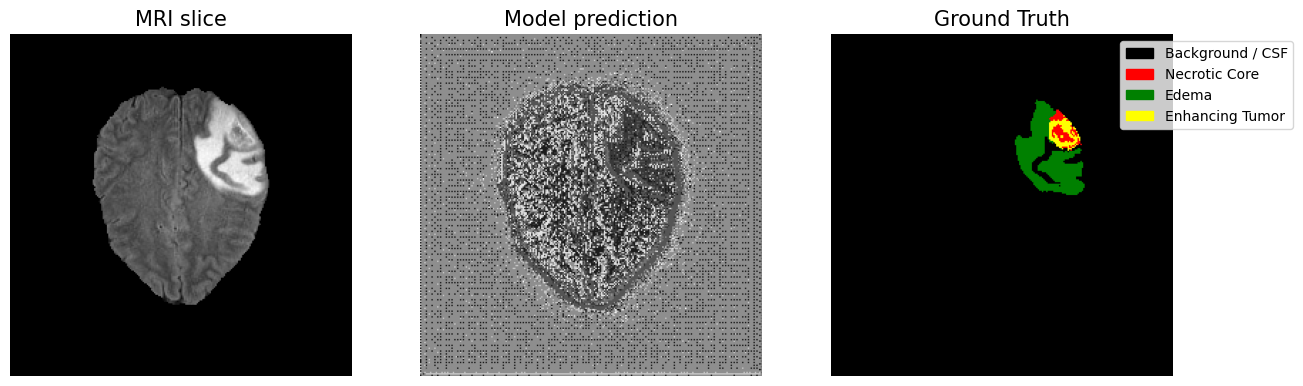

In [44]:
data_slice = img_data[: ,:, 100]
ground_truth_slice = ground_truth_data[:, :, 100]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
print("Slice shape: ", data_slice.shape)
plt.imshow(data_slice.T, cmap='gray', origin='lower')
plt.axis('off')
plt.title("MRI slice", fontsize=15)

plt.subplot(1, 3, 2)
print("Slice shape: ", data_slice.shape)
plt.imshow(output_mask.T, cmap='gray', origin='lower')
plt.axis('off')
plt.title("Model prediction", fontsize=15)

# Black - CSF (healthy tissue) + Placeholder for label 3, which is non-existent in BraTS dataset
# Red - Necrotic core (label 1)
# Green - Edema (label 2)
# Yellow - Enhancing tumour (label 4)
colors = ["black", "red", "green", "black", "yellow"]
cmap = mcolors.ListedColormap(colors)

plt.subplot(1, 3, 3)
plt.imshow(ground_truth_slice.T, cmap=cmap, vmin=0, vmax=4, origin='lower')
plt.axis('off')
plt.title("Ground Truth", fontsize=15)

key_bg = mpatches.Patch(color="black", label="Background / CSF")
key_ncr = mpatches.Patch(color="red", label="Necrotic Core")
key_ed = mpatches.Patch(color="green", label="Edema")
key_et = mpatches.Patch(color="yellow", label="Enhancing Tumor")

plt.legend(
    handles=[key_bg, key_ncr, key_ed, key_et],
    bbox_to_anchor=(1.1, 1),
    loc="upper center",
)